# our dataset  : Airline Passenger Satisfaction — ML Project
## realise par : maggardi et obazzi 

**Models utilise :** KNN · Decision Tree · Random Forest · Naive Bayes · SVM · Logistic Regression

In [15]:
import warnings
warnings.filterwarnings('ignore')



# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Preprocessing
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.preprocessing import StandardScaler

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier , plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB, CategoricalNB

# Evaluation
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score , precision_score, recall_score, f1_score , r2_score


    

In [16]:
# Load the dataset
df_test = pd.read_csv("test.csv")
df_train = pd.read_csv("train.csv")
df = pd.concat([df_train, df_test], ignore_index=True)

# shape of the dataset
print(f'Shape: {df.shape}')
# display the first 5 rows of the dataset 
df.head(5)

Shape: (129880, 25)


,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


In [17]:
# explore the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129880 entries, 0 to 129879
Data columns (total 25 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Unnamed: 0                         129880 non-null  int64  
 1   id                                 129880 non-null  int64  
 2   Gender                             129880 non-null  object 
 3   Customer Type                      129880 non-null  object 
 4   Age                                129880 non-null  int64  
 5   Type of Travel                     129880 non-null  object 
 6   Class                              129880 non-null  object 
 7   Flight Distance                    129880 non-null  int64  
 8   Inflight wifi service              129880 non-null  int64  
 9   Departure/Arrival time convenient  129880 non-null  int64  
 10  Ease of Online booking             129880 non-null  int64  
 11  Gate location                      1298

In [18]:
#check for missing values
df.isnull().sum()

Unnamed: 0                             0
id                                     0
Gender                                 0
Customer Type                          0
Age                                    0
Type of Travel                         0
Class                                  0
Flight Distance                        0
Inflight wifi service                  0
Departure/Arrival time convenient      0
Ease of Online booking                 0
Gate location                          0
Food and drink                         0
Online boarding                        0
Seat comfort                           0
Inflight entertainment                 0
On-board service                       0
Leg room service                       0
Baggage handling                       0
Checkin service                        0
Inflight service                       0
Cleanliness                            0
Departure Delay in Minutes             0
Arrival Delay in Minutes             393
satisfaction    

In [19]:
df['Arrival Delay in Minutes'] = df['Arrival Delay in Minutes'].fillna(df['Arrival Delay in Minutes'].mean())

In [ ]:
print(' Statistical Summary')
df.describe()


=== Statistical Summary ===


,Unnamed: 0,id,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
count,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000
mean,44158.700000,64940.500000,39.427957,1190.316392,2.728696,3.057599,2.756876,2.976925,3.204774,3.252633,3.441361,3.358077,3.383023,3.350878,3.632114,3.306267,3.642193,3.286326,14.713713,15.091129
std,31207.377062,37493.270818,15.119360,997.452477,1.329340,1.526741,1.401740,1.278520,1.329933,1.350719,1.319289,1.334049,1.287099,1.316252,1.180025,1.266185,1.176669,1.313682,38.071126,38.407410
min,0.000000,1.000000,7.000000,31.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,16234.750000,32470.750000,27.000000,414.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,3.000000,3.000000,2.000000,0.000000,0.000000
50%,38963.500000,64940.500000,40.000000,844.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,4.000000,4.000000,3.000000,4.000000,3.000000,0.000000,0.000000
75%,71433.250000,97410.250000,51.000000,1744.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,5.000000,4.000000,4.000000,4.000000,5.000000,4.000000,5.000000,4.000000,12.000000,13.000000
max,103903.000000,129880.000000,85.000000,4983.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1592.000000,1584.000000


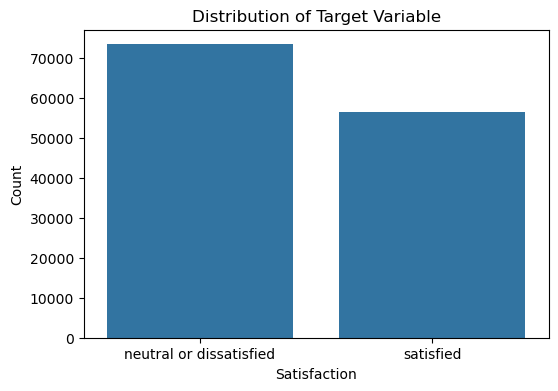

satisfaction
neutral or dissatisfied    56.553742
satisfied                  43.446258
Name: count, dtype: float64


In [21]:
#target variable distribution
plt.figure(figsize=(6,4))
sns.countplot(x='satisfaction', data=df)
plt.title('Distribution of Target Variable')
plt.xlabel('Satisfaction')
plt.ylabel('Count')
plt.show()

print(df['satisfaction'].value_counts() / len(df) * 100)

In [22]:
# Encode the target variable
ordinal_enc = OrdinalEncoder()
df['Class'] = ordinal_enc.fit_transform(df[['Class']])

# Encode categorical variables using one-hot encoding
cols_to_dummy = ['Gender', 'Customer Type', 'Type of Travel']
df = pd.get_dummies(df, columns=cols_to_dummy, drop_first=True)



In [23]:
# Encode the target variable
df['satisfaction'] = ordinal_enc.fit_transform(df[['satisfaction']])

In [24]:
df.head(5)

,Unnamed: 0,id,Age,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,...,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction,Gender_Male,Customer Type_disloyal Customer,Type of Travel_Personal Travel
0,0,70172,13,2.0,460,3,4,3,1,5,...,4,4,5,5,25,18.0,0.0,True,False,True
1,1,5047,25,0.0,235,3,2,3,3,1,...,3,1,4,1,1,6.0,0.0,True,True,False
2,2,110028,26,0.0,1142,2,2,2,2,5,...,4,4,4,5,0,0.0,1.0,False,False,False
3,3,24026,25,0.0,562,2,5,5,5,2,...,3,1,4,2,11,9.0,0.0,False,False,False
4,4,119299,61,0.0,214,3,3,3,3,4,...,4,3,3,3,0,0.0,1.0,True,False,False


In [25]:
X = df.drop(columns=['satisfaction','id','Unnamed: 0'])
y = df[['satisfaction']]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Training set: {X_train.shape}')
print(f'Testing set:  {X_test.shape}')


Training set: (103904, 22)
Testing set:  (25976, 22)


In [26]:
#knn 
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_sc, y_train)
y_pred_knn = knn.predict(X_test_sc)
print("KNN Classification Report:")
print(classification_report(y_test, y_pred_knn))


KNN Classification Report:
              precision    recall  f1-score   support

         0.0       0.92      0.96      0.94     14690
         1.0       0.94      0.89      0.91     11286

    accuracy                           0.93     25976
   macro avg       0.93      0.92      0.93     25976
weighted avg       0.93      0.93      0.93     25976



In [27]:
#best k 
k_values = range(1, 21)
accuracies = []
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_sc, y_train)
    y_pred = knn.predict(X_test_sc)
    accuracies.append(accuracy_score(y_test, y_pred))

best_k = k_values[accuracies.index(max(accuracies))]
print(f"Best k: {best_k}")

Best k: 11


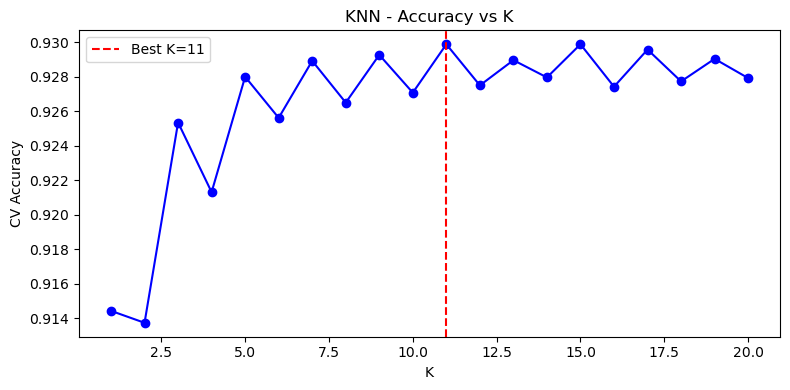

In [28]:
plt.figure(figsize=(8, 4))
plt.plot(k_values, accuracies, marker='o', color='blue')
plt.axvline(x=best_k, color='red', linestyle='--', label=f'Best K={best_k}')
plt.title('KNN - Accuracy vs K')
plt.xlabel('K')
plt.ylabel('CV Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

In [29]:
knn1 = KNeighborsClassifier(n_neighbors=11, metric="euclidean")
knn1.fit(X_train_sc, y_train)
y_pred_knn1 = knn1.predict(X_test_sc)

knn2 = KNeighborsClassifier(n_neighbors=11, metric="manhattan")
knn2.fit(X_train_sc, y_train)
y_pred_knn2 = knn2.predict(X_test_sc)

knn3 = KNeighborsClassifier(n_neighbors=11, metric="chebyshev")
knn3.fit(X_train_sc, y_train)
y_pred_knn3 = knn3.predict(X_test_sc)


In [30]:
print("KNN Classification Report mod 1:")
print(classification_report(y_test, y_pred_knn1))
print("KNN Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_knn1))
print("KNN Accuracy:",accuracy_score(y_test, y_pred_knn1))

KNN Classification Report mod 1:
              precision    recall  f1-score   support

         0.0       0.92      0.97      0.94     14690
         1.0       0.95      0.88      0.92     11286

    accuracy                           0.93     25976
   macro avg       0.93      0.92      0.93     25976
weighted avg       0.93      0.93      0.93     25976

KNN Confusion Matrix:
[[14185   505]
 [ 1316  9970]]
KNN Accuracy: 0.9298968278410841


In [31]:
print("KNN Classification Report MOD 2:")
print(classification_report(y_test, y_pred_knn2))
print("KNN Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_knn2))
print("KNN Accuracy:",accuracy_score(y_test, y_pred_knn2))

KNN Classification Report MOD 2:
              precision    recall  f1-score   support

         0.0       0.93      0.96      0.95     14690
         1.0       0.95      0.91      0.93     11286

    accuracy                           0.94     25976
   macro avg       0.94      0.93      0.94     25976
weighted avg       0.94      0.94      0.94     25976

KNN Confusion Matrix:
[[14124   566]
 [ 1061 10225]]
KNN Accuracy: 0.9373652602402217


In [32]:
print("KNN Classification Report MOD 3:")
print(classification_report(y_test, y_pred_knn3))
print("KNN Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_knn3))
print("KNN Accuracy:",accuracy_score(y_test, y_pred_knn3))

KNN Classification Report MOD 3:
              precision    recall  f1-score   support

         0.0       0.88      0.97      0.92     14690
         1.0       0.95      0.82      0.88     11286

    accuracy                           0.90     25976
   macro avg       0.91      0.89      0.90     25976
weighted avg       0.91      0.90      0.90     25976

KNN Confusion Matrix:
[[14208   482]
 [ 2010  9276]]
KNN Accuracy: 0.9040652910378811


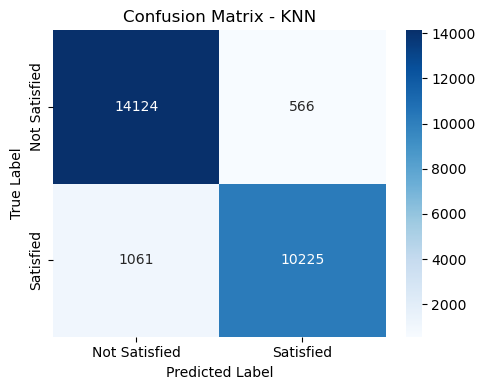

In [33]:
cm_knn = confusion_matrix(y_test, y_pred_knn2)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Not Satisfied', 'Satisfied'],
                yticklabels=['Not Satisfied', 'Satisfied'])
plt.title(f'Confusion Matrix - {"KNN"}')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

In [34]:
# decision tree

dt = DecisionTreeClassifier(criterion='entropy',max_depth=5 ,random_state=42,min_samples_split=5,min_samples_leaf=5)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)



print("Decision Tree Classification Report:")
print(classification_report(y_test, y_pred_dt))
print("\nDecision Tree Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))
print("\nDecision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))


Decision Tree Classification Report:
              precision    recall  f1-score   support

         0.0       0.91      0.92      0.92     14690
         1.0       0.89      0.89      0.89     11286

    accuracy                           0.90     25976
   macro avg       0.90      0.90      0.90     25976
weighted avg       0.90      0.90      0.90     25976


Decision Tree Confusion Matrix:
[[13467  1223]
 [ 1270 10016]]

Decision Tree Accuracy: 0.9040267939636588


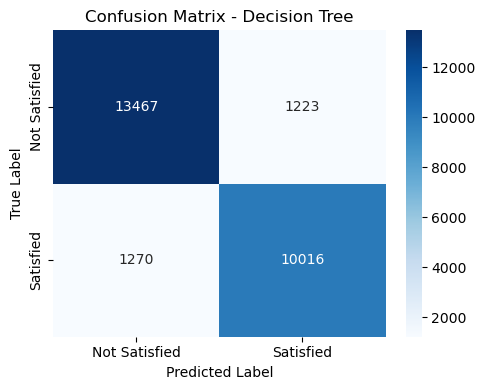

In [35]:
cm_dt = confusion_matrix(y_test, y_pred_dt)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Not Satisfied', 'Satisfied'],
                yticklabels=['Not Satisfied', 'Satisfied'])
plt.title(f'Confusion Matrix - {"Decision Tree"}')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

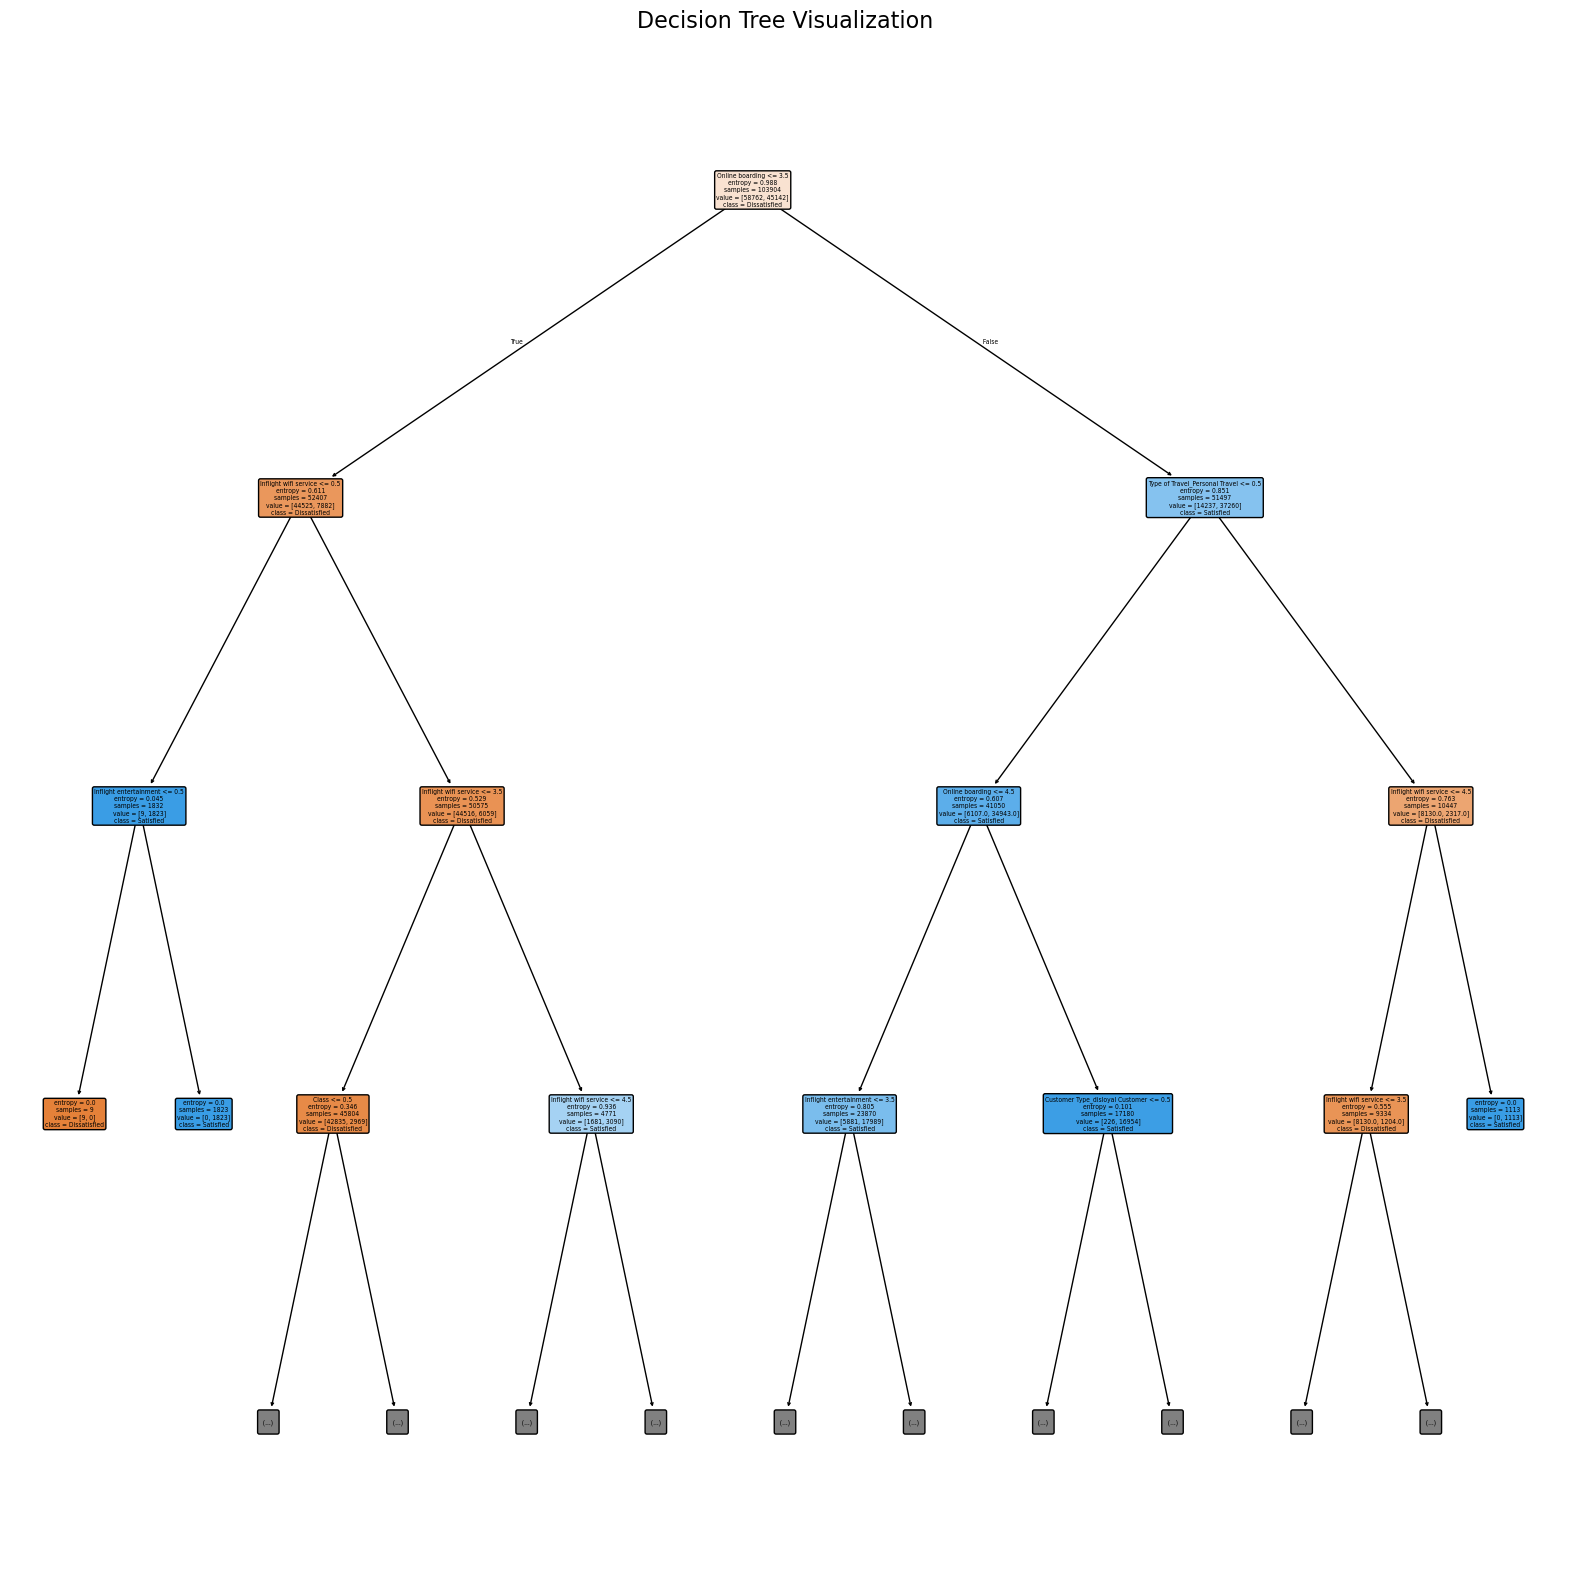

In [36]:
# tree figure
plt.figure(figsize=(20,20))
plot_tree(dt, max_depth=3,filled=True, feature_names=X.columns, class_names=['Dissatisfied', 'Satisfied'], rounded=True)
plt.title('Decision Tree Visualization', fontsize=16)
plt.show()

In [37]:
# naive bayes tout les modeles
nb_models = [GaussianNB(), MultinomialNB(), BernoulliNB(), CategoricalNB()]
L,D=[],[]
for i, nb in enumerate(nb_models):
    L.append(nb.fit(X_train, y_train))
    D.append(nb.predict(X_test))


In [38]:
print("L'accuracy de Model 1 : ", accuracy_score(y_test, D[0]))
print("L'accuracy de Model 2 : ", accuracy_score(y_test, D[1]))
print("L'accuracy de Model 3 : ", accuracy_score(y_test, D[2]))
print("L'accuracy de Model 4 : ", accuracy_score(y_test, D[3]))



L'accuracy de Model 1 :  0.8638358484755159
L'accuracy de Model 2 :  0.6019402525408069
L'accuracy de Model 3 :  0.7771404373267632
L'accuracy de Model 4 :  0.8907453033569449


In [39]:
print("Naive Bayes model 1 Classification Report:")
print(classification_report(y_test, D[0]))

print("Naive Bayes model 2 Classification Report:")
print(classification_report(y_test, D[1]))



Naive Bayes model 1 Classification Report:
              precision    recall  f1-score   support

         0.0       0.87      0.90      0.88     14690
         1.0       0.86      0.82      0.84     11286

    accuracy                           0.86     25976
   macro avg       0.86      0.86      0.86     25976
weighted avg       0.86      0.86      0.86     25976

Naive Bayes model 2 Classification Report:
              precision    recall  f1-score   support

         0.0       0.66      0.62      0.64     14690
         1.0       0.54      0.58      0.56     11286

    accuracy                           0.60     25976
   macro avg       0.60      0.60      0.60     25976
weighted avg       0.61      0.60      0.60     25976



In [40]:
print("Naive Bayes model 3 Classification Report:")
print(classification_report(y_test, D[2]))

print("Naive Bayes model 4 Classification Report:")
print(classification_report(y_test, D[3]))

Naive Bayes model 3 Classification Report:
              precision    recall  f1-score   support

         0.0       0.82      0.77      0.80     14690
         1.0       0.73      0.78      0.75     11286

    accuracy                           0.78     25976
   macro avg       0.77      0.78      0.78     25976
weighted avg       0.78      0.78      0.78     25976

Naive Bayes model 4 Classification Report:
              precision    recall  f1-score   support

         0.0       0.90      0.90      0.90     14690
         1.0       0.88      0.87      0.87     11286

    accuracy                           0.89     25976
   macro avg       0.89      0.89      0.89     25976
weighted avg       0.89      0.89      0.89     25976



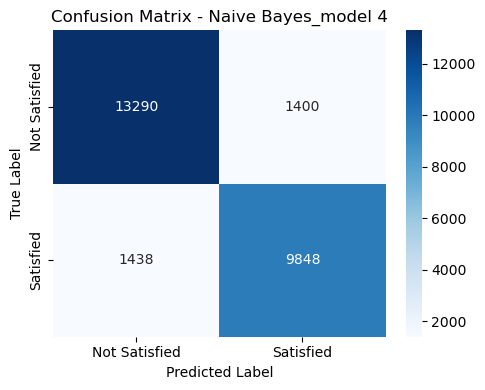

In [41]:
cm_nb = confusion_matrix(y_test, D[3])
plt.figure(figsize=(5, 4))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Not Satisfied', 'Satisfied'],
                yticklabels=['Not Satisfied', 'Satisfied'])
plt.title(f'Confusion Matrix - {"Naive Bayes_model 4"}')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

In [42]:
## echantillonage
X_echantiant, _, y_echantiant, _ = train_test_split( X, y, train_size=0.1,stratify=y, random_state=42)

In [43]:
# Random Forest with best hyperparameters grid search

rf_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10,15,20, 25, 30],
    'n_jobs': [-1],
    'random_state': [42],   
    'oob_score': [True]
}

grid_rf = GridSearchCV(RandomForestClassifier(), rf_grid, cv=4, n_jobs=-1)
grid_rf.fit(X_echantiant, y_echantiant)                   

,estimator,RandomForestClassifier()
,param_grid,"{'max_depth': [10, 15, ...], 'n_estimators': [50, 100, ...], 'n_jobs': [-1], 'oob_score': [True], ...}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,4
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,200


In [44]:
y_pred_rf = grid_rf.predict(X_test)
print("\nBest Hyperparameters for Random Forest:", grid_rf.best_params_)
print("\nBest Random Forest Estimator:", grid_rf.best_estimator_)

print("\nRandom Forest Classification Report:")   
print(classification_report(y_test, y_pred_rf))



Best Hyperparameters for Random Forest: {'max_depth': 25, 'n_estimators': 200, 'n_jobs': -1, 'oob_score': True, 'random_state': 42}

Best Random Forest Estimator: RandomForestClassifier(max_depth=25, n_estimators=200, n_jobs=-1,
                       oob_score=True, random_state=42)

Random Forest Classification Report:
              precision    recall  f1-score   support

         0.0       0.95      0.97      0.96     14690
         1.0       0.96      0.93      0.94     11286

    accuracy                           0.95     25976
   macro avg       0.95      0.95      0.95     25976
weighted avg       0.95      0.95      0.95     25976



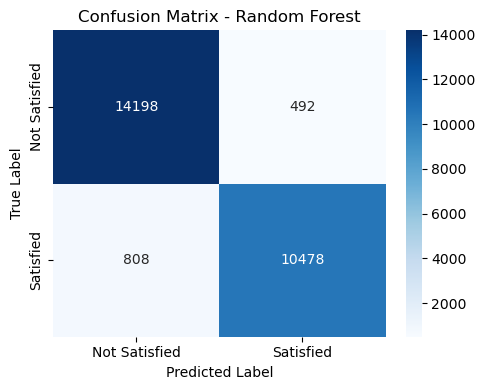

In [45]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Not Satisfied', 'Satisfied'],
                yticklabels=['Not Satisfied', 'Satisfied'])
plt.title(f'Confusion Matrix - {"Random Forest"}')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

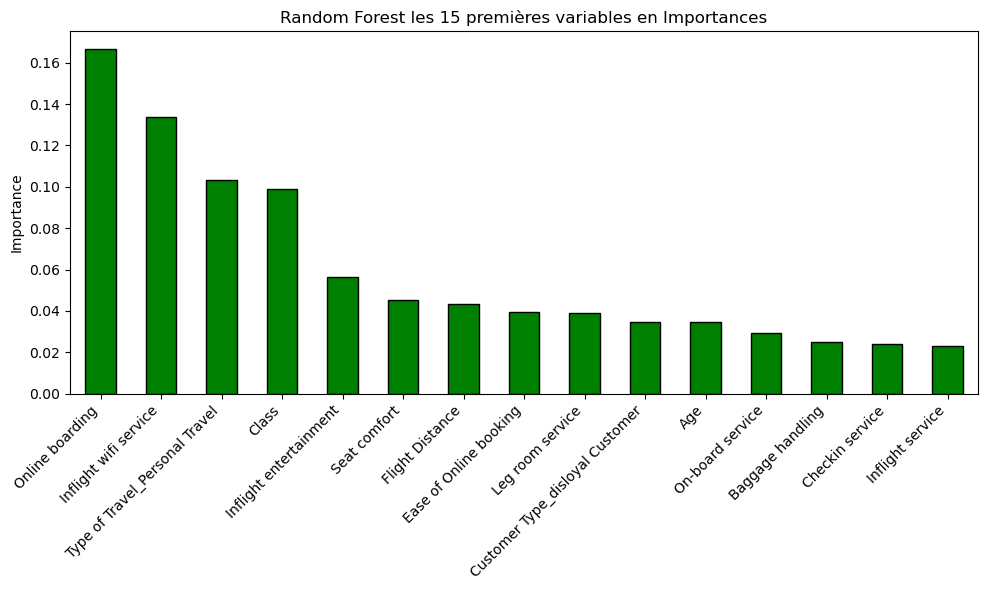

In [46]:
feat_imp = pd.Series(grid_rf.best_estimator_.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(10, 6))
feat_imp.head(15).plot(kind='bar', color='Green', edgecolor='black')
plt.title('Random Forest les 15 premières variables en Importances')
plt.ylabel('Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [47]:
# svm avec echantillonage et grid search
scaler = StandardScaler()

X_echantiant_sc = scaler.fit_transform(X_echantiant)


param_grid = {'C': [0.1, 1, 10],'gamma': ['auto'],'kernel': ['rbf', 'linear', 'poly']
}


grid_svm = GridSearchCV(SVC(), param_grid, cv=4, n_jobs=-1)
grid_svm.fit(X_echantiant_sc, y_echantiant)
y_pred_svm = grid_svm.predict(X_test_sc)

In [48]:
print("\nBest Hyperparameters for SVM:", grid_svm.best_params_)
print("\nBest SVM Estimator:", grid_svm.best_estimator_)
print("SVM Classification Report:")
print(classification_report(y_test, y_pred_svm))


Best Hyperparameters for SVM: {'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}

Best SVM Estimator: SVC(C=10, gamma='auto')
SVM Classification Report:
              precision    recall  f1-score   support

         0.0       0.94      0.96      0.95     14690
         1.0       0.95      0.93      0.94     11286

    accuracy                           0.94     25976
   macro avg       0.94      0.94      0.94     25976
weighted avg       0.94      0.94      0.94     25976



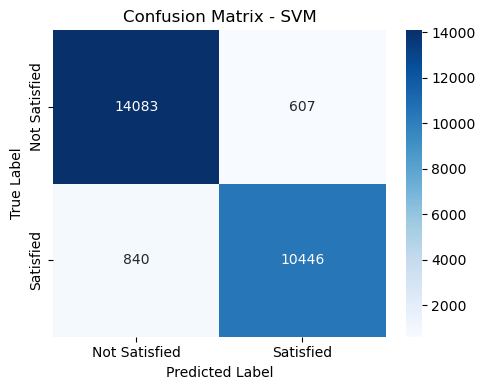

In [49]:
cm_svm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Not Satisfied', 'Satisfied'],
                yticklabels=['Not Satisfied', 'Satisfied'])
plt.title('Confusion Matrix - SVM')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

In [50]:
# Logistic Regression
log_r = LogisticRegression(random_state=42, max_iter=1000)
log_r.fit(X_train_sc, y_train)
y_pred_logr = log_r.predict(X_test_sc)
print("Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred_logr))
print("Logistic Regression Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_logr))
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_logr))

Logistic Regression Classification Report:
              precision    recall  f1-score   support

         0.0       0.88      0.91      0.89     14690
         1.0       0.87      0.83      0.85     11286

    accuracy                           0.87     25976
   macro avg       0.87      0.87      0.87     25976
weighted avg       0.87      0.87      0.87     25976

Logistic Regression Confusion Matrix:
[[13300  1390]
 [ 1864  9422]]
Logistic Regression Accuracy: 0.8747305204804435


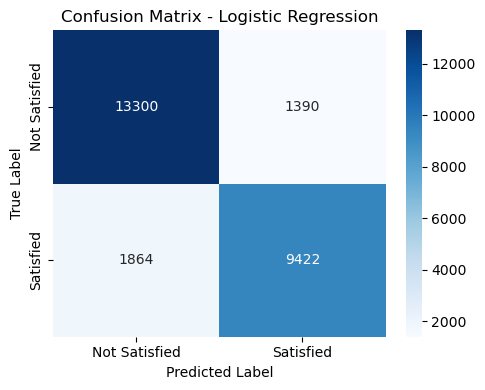

In [51]:
cm_logr = confusion_matrix(y_test, y_pred_logr)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_logr, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Not Satisfied', 'Satisfied'],
                yticklabels=['Not Satisfied', 'Satisfied'])
plt.title(f'Confusion Matrix - {"Logistic Regression"}')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()


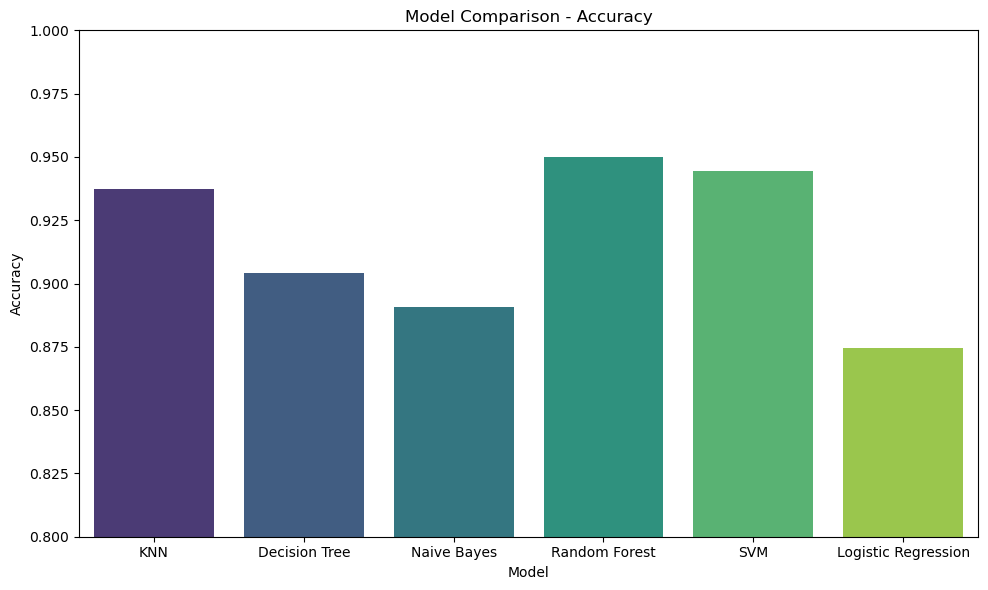

In [ ]:
# compare models with accuracy score
models = ['KNN', 'Decision Tree', 'Naive Bayes', 'Random Forest', 'SVM', 'Logistic Regression']
accuracies = [accuracy_score(y_test, y_pred_knn2), accuracy_score(y_test, y_pred_dt),
               accuracy_score(y_test, D[3]), accuracy_score(y_test, y_pred_rf),
                 accuracy_score(y_test, y_pred_svm), accuracy_score(y_test, y_pred_logr)]
plt.figure(figsize=(10, 6))
sns.barplot(x=models, y=accuracies, palette='viridis')
plt.title('Model Comparison - Accuracy')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.ylim(0.8, 1)
plt.tight_layout()
plt.show()

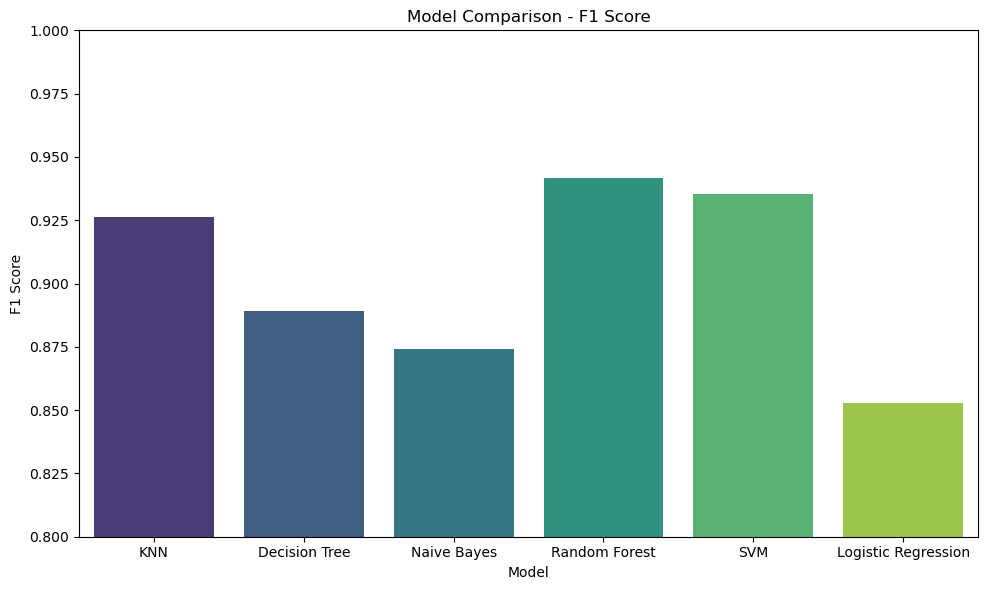

In [ ]:
# compare models f1 score
from sklearn.metrics import f1_score
f1_scores = [f1_score(y_test, y_pred_knn2), f1_score(y_test, y_pred_dt), f1_score(y_test, D[3]), f1_score(y_test, y_pred_rf), f1_score(y_test, y_pred_svm), f1_score(y_test, y_pred_logr)]
plt.figure(figsize=(10, 6))
sns.barplot(x=models, y=f1_scores, palette='viridis')
plt.title('Model Comparison - F1 Score')
plt.xlabel('Model')
plt.ylabel('F1 Score')
plt.ylim(0.8, 1)
plt.tight_layout()
plt.show()


In [ ]:
## Observations

### 1. Best Model — Random Forest (95%)
- Ensemble learning clearly dominates on this dataset
- Combining 200 trees with depth=25 captures complex patterns
  that single models miss
- Feature importance reveals that **Online Boarding**, 
  **Inflight WiFi**, and **Type of Travel** are the strongest 
  predictors of satisfaction

### 2. KNN & SVM (94%)
- Both perform nearly as well as Random Forest
- Success is strongly linked to **proper feature scaling** (StandardScaler)
- Without scaling, both models would have scored much lower

### General Conclusion
Tree-based and kernel methods outperform linear models on this dataset,
confirming that passenger satisfaction depends on **complex, non-linear 
interactions** between service quality features.
A satisfied passenger is not defined by one factor alone — 
it is the **combination** of wifi, comfort, boarding experience, and travel type.